In [16]:
import math

from scipy.io import arff
from operator import index

import numpy as np
from sklearn.metrics import roc_auc_score
from sklearn.neighbors import NearestNeighbors, KernelDensity
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import scipy.stats
from scipy.stats import expon, skew, norm,gamma, anderson,goodness_of_fit, monte_carlo_test, probplot, skewnorm
from scipy import integrate
from sklearn.metrics import auc
import seaborn as sns
import math

from statsmodels.sandbox.distributions.gof_new import kstest

plt.rcParams['figure.figsize'] = [15, 7]
import warnings
from scipy import stats

warnings.filterwarnings('ignore')

In [17]:
mainDataFrame = np.array([])
def setupDf(fileName):
    arff_file = arff.loadarff(f'./{fileName}') # import the attribute-relation file format
    df4 = pd.DataFrame(arff_file[0])
    if fileName[0] == 'c': # checks if the file is a synthetic dataset
        X = df4.iloc[:,:2].values
        y = df4.iloc[:,2].values
        le = LabelEncoder()
        y = le.fit_transform(y)
    else:
        #drop the outlier and id columns for the independent variables.
        X = df4.drop(columns=['outlier','id']).values
        #get outlier values
        y = df4['outlier'].values
        le = LabelEncoder()
        #encoded the variables as 0=non-outlier, 1=outlier
        y = le.fit_transform(y)
    return X, y

def main(X, y, n):
    #find the nearestNeighbors
    nn = NearestNeighbors(n_neighbors=n,p=1)
    nn.fit(X, y)
    #return the dist of each and the nearest neighbors
    dist, knn = nn.kneighbors(X)  # returns N index neighbors including self
    return knn, dist

def generateArr(newDist, distanceMetric='max'):
    arr = []
    #returns an array based on the median and max values
    for x in newDist:  # finds the distance away from that point (index 0)
        if distanceMetric == 'median':
            arr += [np.median(x)]
        elif distanceMetric == 'sum':  # min + median + max
            arr += [x[1] + np.max(x) + np.median(x)]
        elif distanceMetric == 'max':
            arr += [np.max(x)]
        elif distanceMetric == 'minMax':
            arr += [np.max(x) + x[1]]
        elif distanceMetric == 'medMax':
            arr += [np.median(x) + np.max(x)]
        elif distanceMetric == 'min':
            arr += [x[1]]

    return arr

def outputResults(X,y,lowerRange=2,upperRange=70):
    tots = []
    posNeg4 = []
    for v in range(lowerRange,upperRange):
        knn, distReturn = main(X, y, v) # returns index and distance of points
        distReturn = np.array(distReturn)
        arr = generateArr(distReturn, distanceMetric="max") # return arr of max values
        arr = np.log(arr)
        arr[~np.isfinite(arr)] = 0
        params = stats.skewnorm.fit(arr) # fit params for gamma distribution
        posNeg4 = []
        spaceStep4 = np.linspace(0,.99,30) # threshold from 0 to .99, 30 samples
        for e in spaceStep4:
            newArr = arr > skewnorm.ppf(e,params[0],loc=params[1], scale=params[2]) # if arr value is outside threshold add to new array
            posNeg4.append([((y[newArr] == 1).sum() / (y == 1).sum()), (y[newArr] != 1).sum()/ ((y != 1).sum())]) # True positive rate, false positive rate

        posNeg4 = np.array(posNeg4)
        arrtest1, arrtest2 = np.split(posNeg4, 2,axis=1) # split the array
        tots += [auc(arrtest2, arrtest1)] # return the area under the curve

    return tots

def printResults(arr):
    arr = np.nan_to_num(arr)
    arr = list(arr)
    print(max(arr),arr.index(max(arr))+2,arr) #print the max values, the k value, and the array
    global mainDataFrame
    mainDataFrame = np.append(mainDataFrame,sortIndex(arr))

def qqPlots(X,y,kValue,name):
    knn, distReturn = main(X, y, kValue)
    distReturn = np.array(distReturn)
    arr = generateArr(distReturn, distanceMetric="max")
    arr = np.log(arr)
    params = skewnorm.fit(arr)
    print(f"a: {params[0]} Loc: {params[1]}, Scale: {params[2]}")
    print(skew(arr),np.var(arr))
    fig, ax = plt.subplots(2,1)
    results = probplot(arr,dist=stats.skewnorm, plot=ax[0],sparams=(params[0],params[1],params[2]),rvalue=True)
    fig.suptitle(name)
    dista = plt.hist(arr,bins=int(np.sqrt(len(arr))),density=True)
    sns.kdeplot(arr,bw=.3)
    plt.xlabel("Maximum Manhattan Distance")
    plt.ylabel("Density")
    plt.show()

def sortIndex(arrV):
    indexArr = []
    for a in range(len(arrV)):
        indexArr += [[arrV[a],a+2]]
    indexArr = np.array(indexArr)
    return indexArr[indexArr[:,0].argsort()[::-1]][:3]

0.7598778449785135 35 [0.7434446124462838, 0.7504476364793888, 0.7483188763329619, 0.7483188763329619, 0.7535015120165526, 0.7543470475887314, 0.7550632659557536, 0.7543768900206907, 0.7555705872990609, 0.7563365430526817, 0.7540983606557377, 0.7552721629794683, 0.7565454400763967, 0.7558192742320546, 0.7563564380073213, 0.7567642845774313, 0.7581569314021964, 0.7572218685341398, 0.7556203246856598, 0.7551030558650326, 0.7557396944134968, 0.7564260703485596, 0.7571422887155818, 0.7580276141970396, 0.7573810281712557, 0.7567841795320708, 0.7579181919465223, 0.7578883495145631, 0.7583857233805507, 0.7587438325640617, 0.7581171414929174, 0.7587139901321024, 0.7584752506764284, 0.7598778449785135, 0.758972624542416, 0.7584951456310679, 0.7596192105681998, 0.7585846729269456, 0.7587637275187011, 0.7582763011300333, 0.7587139901321024, 0.7586145153589048, 0.7597087378640777, 0.7591417316568517, 0.7583956708578703, 0.758893044723858, 0.7569831290784657, 0.7569234442145473, 0.7569930765557854,

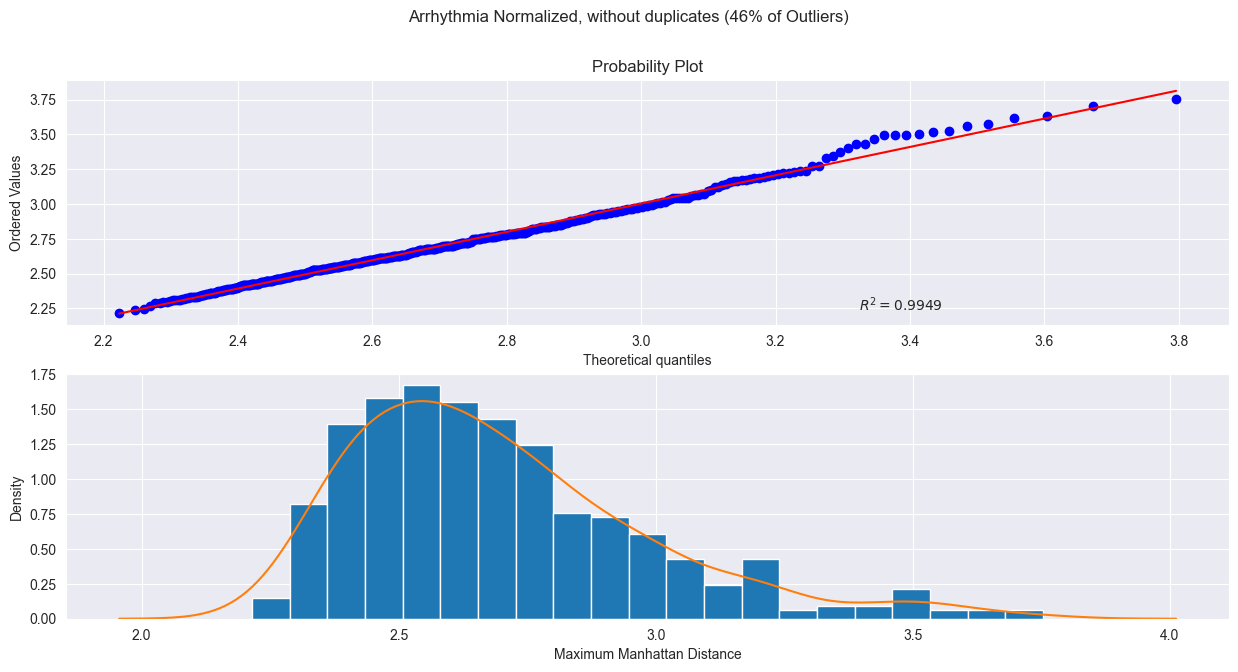

In [18]:
X, y = setupDf("real/Arrhythmia_withoutdupl_norm_46.arff")
endResults = outputResults(X,y)
printResults(endResults)
qqPlots(X,y,35,"Arrhythmia Normalized, without duplicates (46% of Outliers)")

0.7391581632653061 6 [0.6457624716553289, 0.6974206349206349, 0.7355442176870748, 0.7161281179138321, 0.7391581632653061, 0.6941609977324263, 0.6861536281179139, 0.6764455782312926, 0.6537698412698413, 0.6484552154195011, 0.6454790249433107, 0.6405187074829932, 0.6298894557823129, 0.613874716553288, 0.5994897959183674, 0.5907029478458051, 0.579861111111111, 0.584467120181406, 0.5846088435374149, 0.5743339002267573, 0.5732709750566894, 0.5682397959183674, 0.575609410430839, 0.5666808390022676, 0.5663973922902494, 0.5600198412698413, 0.5598781179138322, 0.5600198412698413, 0.5529336734693877, 0.5573979591836734, 0.5519416099773242, 0.5558390022675737, 0.5525793650793651, 0.5576814058956916, 0.5517998866213152, 0.5540674603174602, 0.5525793650793651, 0.5553429705215419, 0.5508078231292517, 0.5457766439909297, 0.5458475056689343, 0.5442885487528344, 0.53734410430839, 0.5374149659863946, 0.5334467120181405, 0.5364937641723355, 0.5331632653061225, 0.5308248299319728, 0.5262188208616779, 0.51

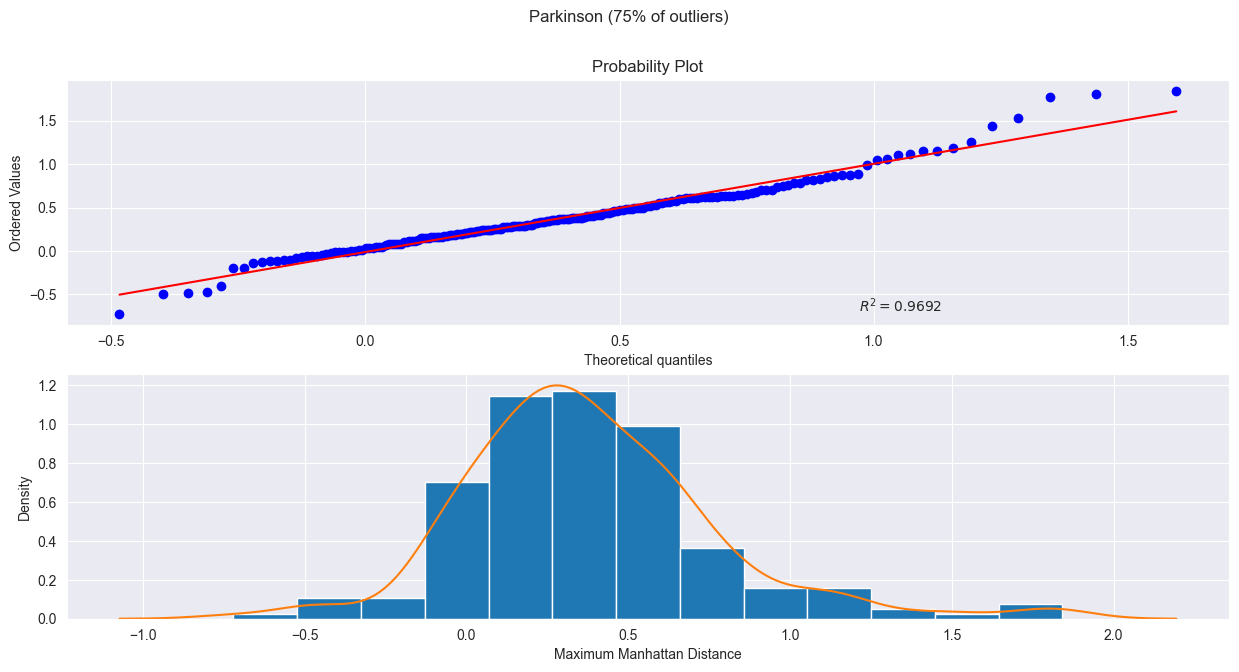

In [19]:
X, y = setupDf("real/Parkinson_withoutdupl_norm_75.arff")
endResults = outputResults(X,y)
printResults(endResults)
qqPlots(X,y,6,"Parkinson (75% of outliers)")

0.8456538461538463 5 [0.3216153846153846, 0.45738461538461544, 0.6226153846153846, 0.8456538461538463, 0.8383461538461539, 0.822423076923077, 0.8164615384615385, 0.7993846153846154, 0.7975769230769232, 0.7945000000000001, 0.7758461538461539, 0.7748076923076923, 0.7726153846153846, 0.7761153846153847, 0.7723076923076923, 0.7685769230769232, 0.7685384615384616, 0.7532692307692309, 0.7582692307692309, 0.754923076923077, 0.755423076923077, 0.7562692307692308, 0.7515000000000001, 0.753576923076923, 0.7484999999999999, 0.7432692307692307, 0.7414230769230769, 0.7431923076923077, 0.7376923076923078, 0.7358076923076924, 0.734653846153846, 0.7378076923076923, 0.7380384615384614, 0.7309230769230768, 0.7359615384615383, 0.735423076923077, 0.7317307692307692, 0.7343076923076924, 0.7333076923076922, 0.7331153846153845, 0.7313461538461539, 0.7228076923076923, 0.7198846153846155, 0.7153846153846154, 0.7145769230769231, 0.710423076923077, 0.7098076923076924, 0.710730769230769, 0.7142307692307692, 0.714

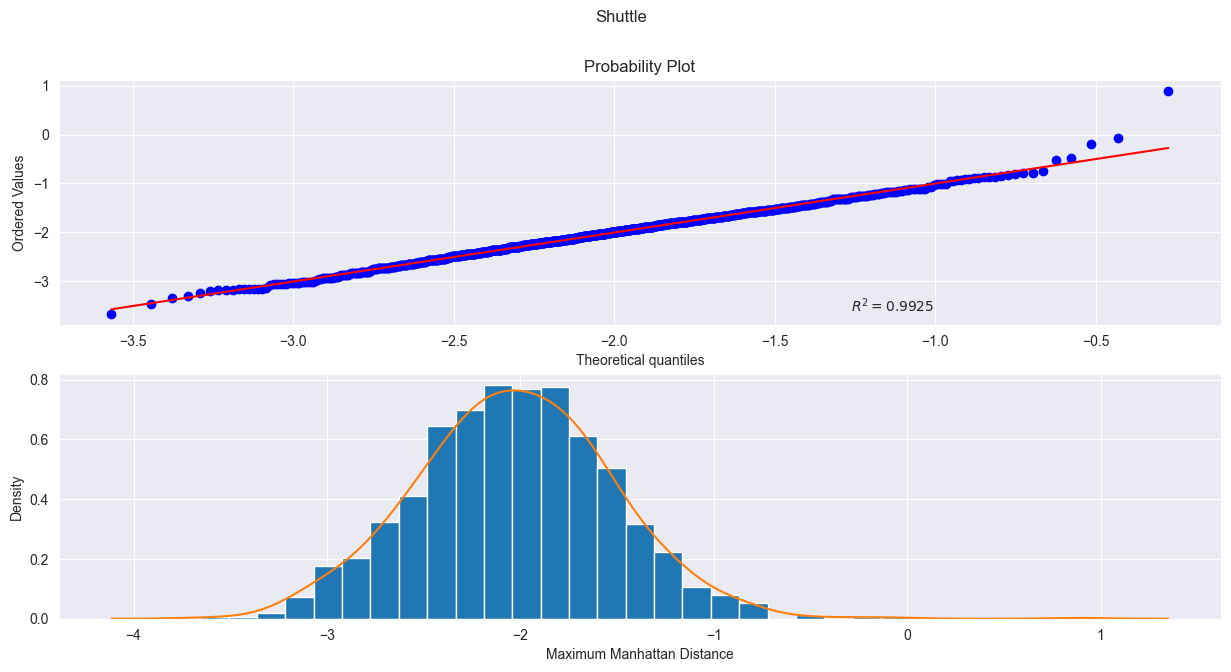

In [20]:
X, y = setupDf("real/Shuttle_withoutdupl_norm_v10.arff")
endResults = outputResults(X,y)
printResults(endResults)
qqPlots(X,y,5,"Shuttle")

0.996244131455399 60 [0.9791079812206571, 0.9795774647887324, 0.9896713615023475, 0.988262910798122, 0.984037558685446, 0.9920187793427232, 0.9809859154929577, 0.9830985915492957, 0.9852112676056339, 0.9870892018779343, 0.9894366197183097, 0.9873239436619718, 0.9887323943661972, 0.9887323943661971, 0.9873239436619718, 0.9884976525821596, 0.9901408450704225, 0.9884976525821596, 0.9901408450704225, 0.9901408450704225, 0.9901408450704227, 0.9901408450704227, 0.9901408450704227, 0.9934272300469483, 0.9924882629107981, 0.9924882629107981, 0.9924882629107983, 0.9924882629107983, 0.9924882629107981, 0.9924882629107983, 0.9924882629107982, 0.9943661971830987, 0.9924882629107983, 0.9924882629107982, 0.9943661971830987, 0.9943661971830987, 0.9943661971830987, 0.9943661971830986, 0.9943661971830986, 0.9943661971830987, 0.9943661971830987, 0.9943661971830987, 0.9924882629107981, 0.9924882629107983, 0.9924882629107981, 0.9924882629107983, 0.9924882629107983, 0.9924882629107982, 0.9924882629107982, 

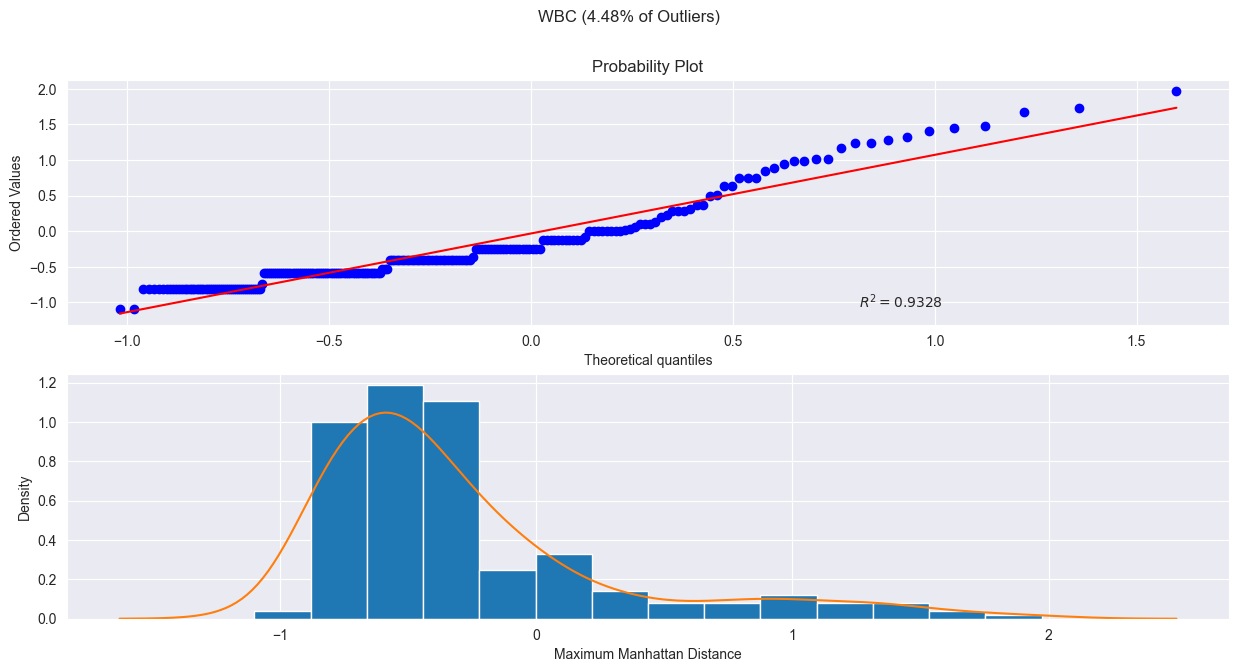

In [21]:
X, y = setupDf("real/WBC_withoutdupl_norm_v10.arff")
endResults = outputResults(X,y)
printResults(endResults)
qqPlots(X,y,60,"WBC (4.48% of Outliers)")

0.6501662617516455 46 [0.4093269143779073, 0.4741252940267339, 0.5087749781364737, 0.5306145912651442, 0.5463990913443052, 0.5708227471143915, 0.5861428828567335, 0.59141451361193, 0.606632399672801, 0.6179091966284934, 0.6223753166441749, 0.6229983564659493, 0.6269334378133458, 0.6278146934205864, 0.6308904298067716, 0.6327906482535565, 0.6358365814491749, 0.6377104128813867, 0.6387060514848348, 0.6403042328540948, 0.6411725305523933, 0.6423044627980791, 0.6450303356428253, 0.6471024230818526, 0.6469774381601466, 0.646781891534292, 0.6464575904132206, 0.6460944155653228, 0.6461033683024102, 0.6456613858083098, 0.6458138179371387, 0.6456963721624535, 0.6456481923010231, 0.6458705971381398, 0.6464324991895417, 0.6466529014407308, 0.6480901691407633, 0.648599297163019, 0.6494526343664476, 0.6496586651186284, 0.6494227133767085, 0.6497408889408253, 0.6496768061911476, 0.6500813285484881, 0.6501662617516455, 0.6499020382083971, 0.6498315943034206, 0.6499913299809259, 0.6491119591604405, 0.

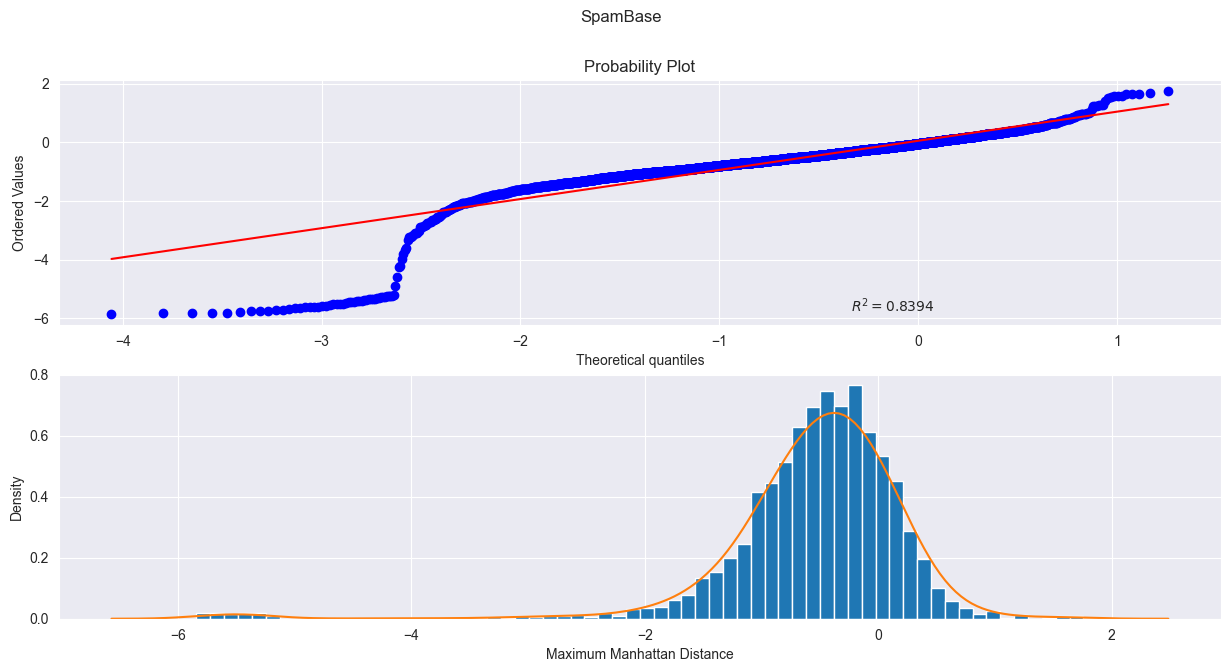

In [22]:
X, y = setupDf("real/SpamBase_withoutdupl_norm_40.arff")
endResults = outputResults(X,y)
printResults(endResults)
qqPlots(X,y,46,"SpamBase")

0.5317035367056503 26 [0.4620966605608003, 0.5095110610116952, 0.5193039312385516, 0.5212061434408903, 0.5231083556432294, 0.5228969987318585, 0.5183175989854868, 0.5195152881499224, 0.5268423277441173, 0.5253628293645203, 0.5309990136677468, 0.5278286599971818, 0.5293786106805694, 0.5250810201493589, 0.5269127800479076, 0.5238128786811329, 0.5236015217697619, 0.5288854445540369, 0.5300831337184725, 0.5283922784275046, 0.5258559954910524, 0.5250105678455685, 0.5190925743271803, 0.5249401155417781, 0.5317035367056503, 0.525151472453149, 0.520290263491616, 0.520924334225729, 0.523037903339439, 0.5212061434408903, 0.5213470480484712, 0.5203607157954065, 0.5166267436945189, 0.5166267436945188, 0.513315485416373, 0.5141609130618571, 0.5119768916443567, 0.5130336762012118, 0.5142313653656473, 0.5167676483020994, 0.5117655347329858, 0.5103564886571791, 0.5122587008595181, 0.5129632238974213, 0.5114837255178245, 0.5090178948851628, 0.503804424404678, 0.503804424404678, 0.5014090460758067, 0.50

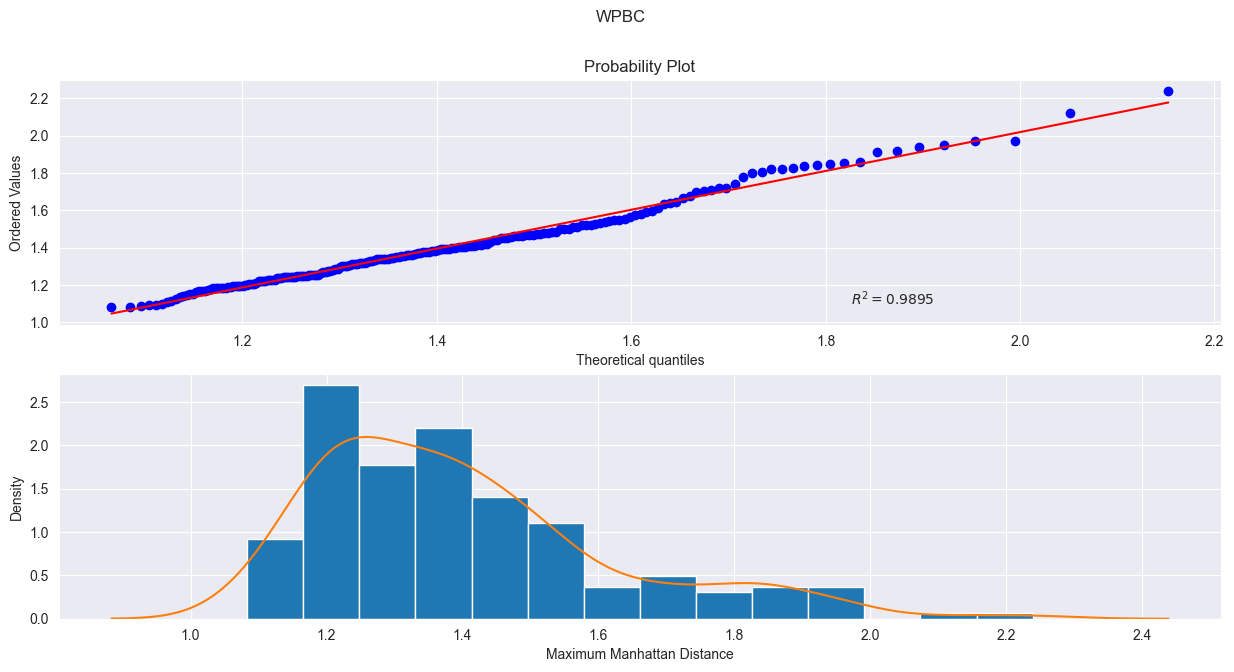

In [23]:
X, y = setupDf("real/WPBC_withoutdupl_norm.arff")
endResults = outputResults(X, y)
printResults(endResults)
qqPlots(X,y,26,"WPBC")

0.7005277777777777 68 [0.6120000000000001, 0.6248888888888889, 0.6175, 0.6216111111111109, 0.6194722222222222, 0.6306944444444444, 0.6311944444444444, 0.6377777777777778, 0.6461666666666668, 0.6444444444444444, 0.6486388888888889, 0.6538333333333334, 0.6536388888888889, 0.6603611111111112, 0.6631666666666667, 0.6624722222222221, 0.6635833333333333, 0.6609722222222224, 0.660111111111111, 0.6593055555555556, 0.6621388888888888, 0.6641666666666668, 0.6591944444444445, 0.6549722222222221, 0.6643611111111112, 0.6636388888888889, 0.6623888888888888, 0.6620277777777779, 0.6631944444444444, 0.6601111111111111, 0.6583055555555557, 0.6586388888888888, 0.6611111111111111, 0.662861111111111, 0.6622777777777777, 0.6619999999999998, 0.6621944444444445, 0.6647222222222222, 0.66575, 0.6687500000000001, 0.670888888888889, 0.6700000000000002, 0.6713611111111112, 0.6723611111111112, 0.6733333333333332, 0.6736944444444445, 0.6768333333333335, 0.6758333333333334, 0.6782777777777779, 0.6804999999999999, 0.6

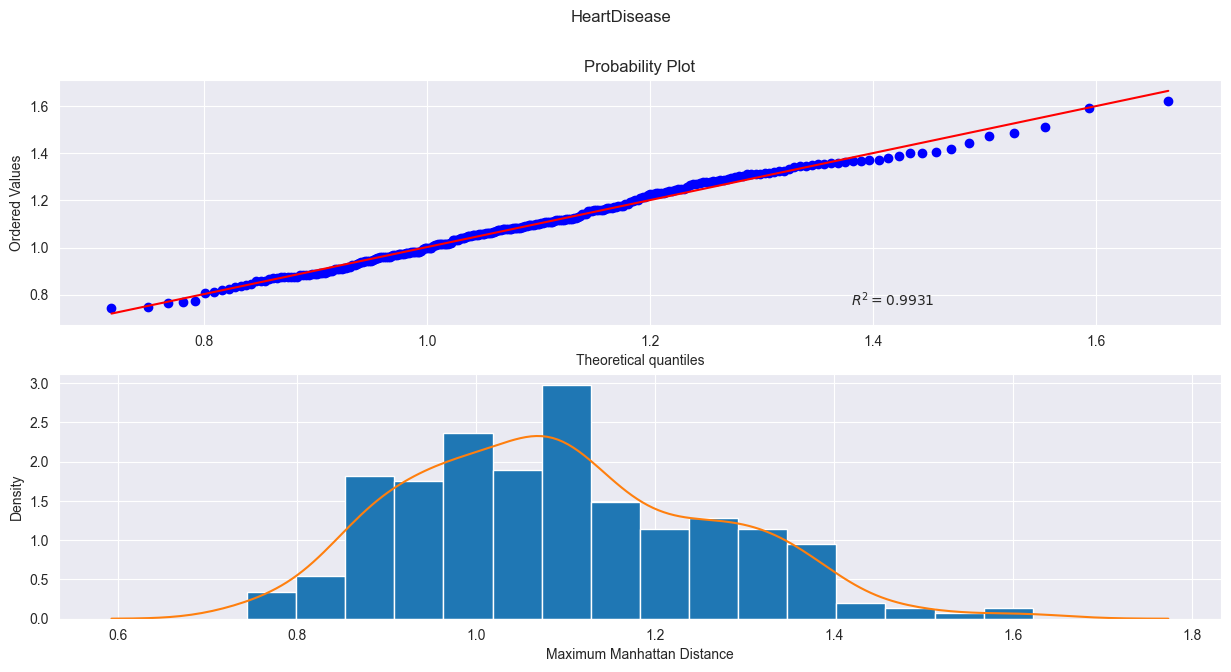

In [24]:
X, y = setupDf("real/HeartDisease_withoutdupl_norm_44.arff")
endResults = outputResults(X, y)
printResults(endResults)
qqPlots(X,y,68,"HeartDisease")

0.8761517615176151 10 [0.8712737127371274, 0.835772357723577, 0.8615176151761517, 0.8609756097560975, 0.865040650406504, 0.8742547425474253, 0.8731707317073171, 0.8750677506775068, 0.8761517615176151, 0.8718157181571815, 0.8693766937669376, 0.8644986449864498, 0.8617886178861789, 0.8653116531165311, 0.8685636856368564, 0.8666666666666666, 0.8658536585365854, 0.8607046070460705, 0.8639566395663956, 0.8642276422764228, 0.8601626016260163, 0.8208672086720867, 0.8130081300813009, 0.8054200542005421, 0.8037940379403794, 0.7986449864498645, 0.7905149051490514, 0.7861788617886178, 0.7880758807588075, 0.7837398373983739, 0.7875338753387533, 0.7842818428184283, 0.7818428184281844, 0.7791327913279134, 0.7804878048780489, 0.7831978319783198, 0.7915989159891599, 0.7910569105691058, 0.791869918699187, 0.7915989159891599, 0.7907859078590787, 0.7924119241192412, 0.7902439024390243, 0.7886178861788617, 0.7883468834688345, 0.7867208672086721, 0.7859078590785908, 0.7834688346883469, 0.7878048780487805, 

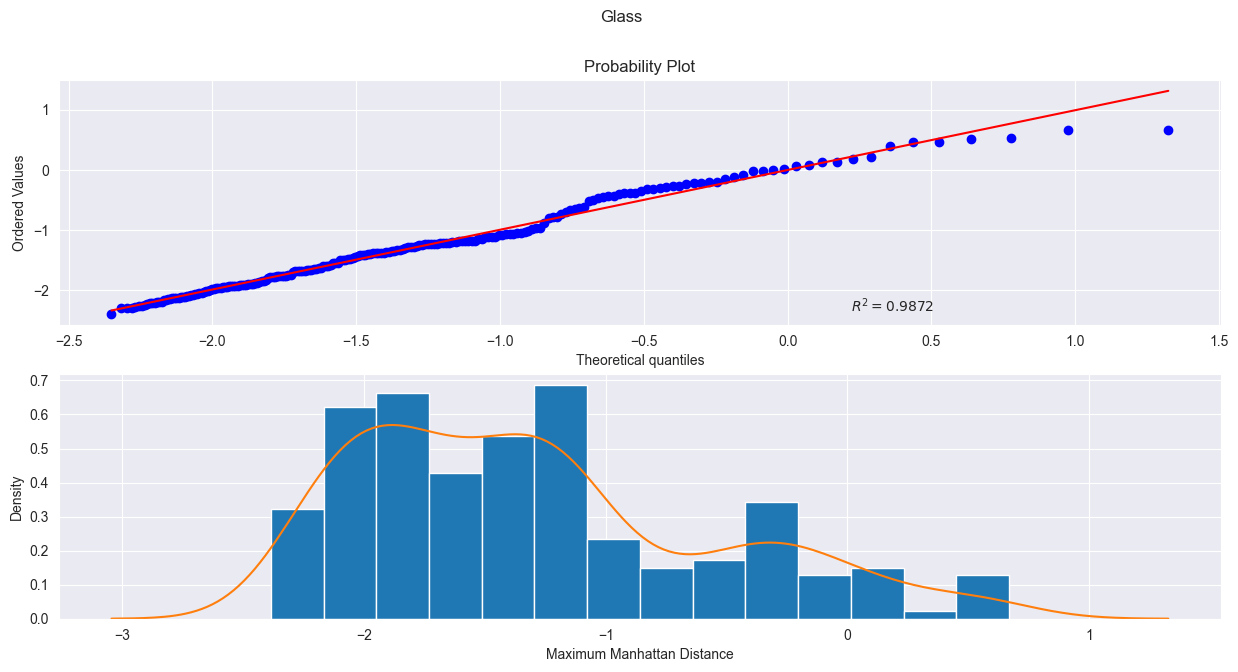

In [25]:
X, y = setupDf("real/Glass_withoutdupl_norm.arff")
endResults = outputResults(X, y)
printResults(endResults)
qqPlots(X,y,10,"Glass")

0.7881745120551091 26 [0.6216991963260621, 0.6102181400688864, 0.6578645235361653, 0.6733639494833524, 0.6636050516647531, 0.6750861079219288, 0.6911595866819749, 0.7169919632606199, 0.7003444316877153, 0.7210103329506314, 0.7210103329506314, 0.7278989667049369, 0.7273249138920781, 0.7336394948335246, 0.7422502870264066, 0.75947187141217, 0.7474167623421356, 0.7554535017221584, 0.7611940298507462, 0.7726750861079219, 0.7715269804822044, 0.7743972445464983, 0.7743972445464984, 0.7847301951779564, 0.7881745120551091, 0.7732491389207807, 0.7789896670493685, 0.7755453501722159, 0.7743972445464983, 0.7732491389207806, 0.7732491389207807, 0.7766934557979334, 0.7749712973593571, 0.7721010332950632, 0.7755453501722158, 0.7715269804822045, 0.7721010332950632, 0.7789896670493686, 0.7743972445464984, 0.7663605051664754, 0.7663605051664754, 0.7594718714121699, 0.7594718714121698, 0.7583237657864524, 0.7594718714121699, 0.7594718714121699, 0.7520091848450059, 0.7525832376578644, 0.7479908151549942,

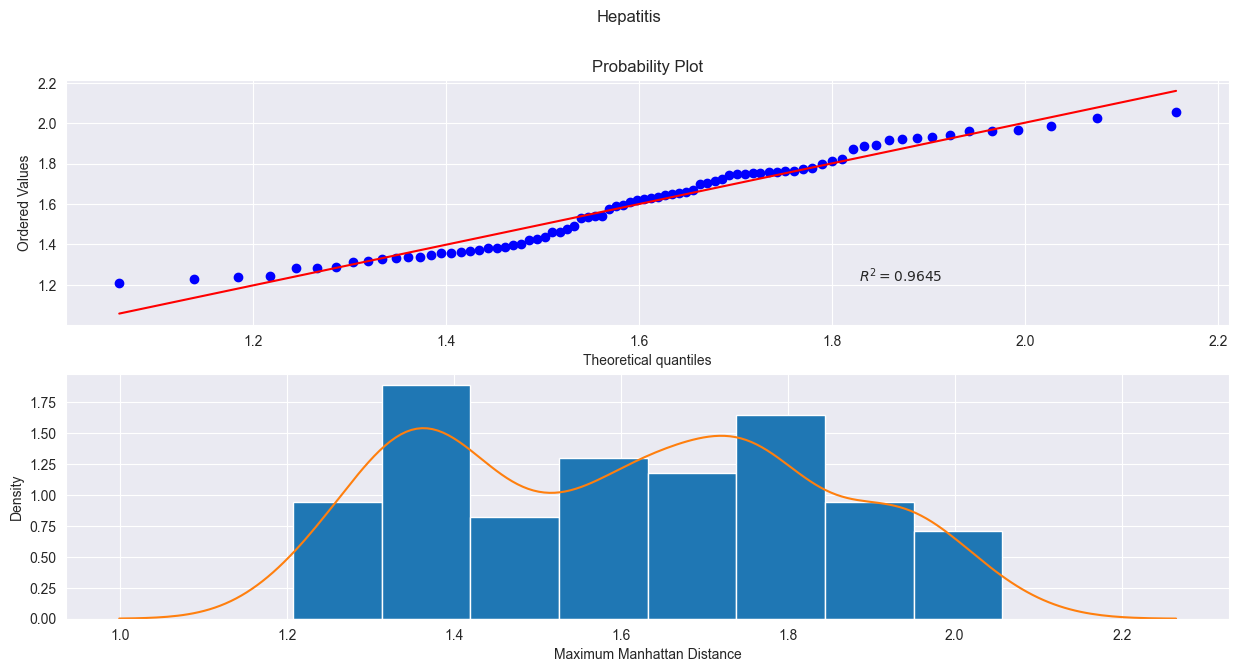

In [26]:
X, y = setupDf("real/Hepatitis_withoutdupl_norm_16.arff")
endResults = outputResults(X, y)
printResults(endResults)
qqPlots(X,y,26,"Hepatitis")

0.7371902985074629 67 [0.677089552238806, 0.6927761194029851, 0.7070858208955223, 0.7079776119402985, 0.7125671641791045, 0.7157761194029852, 0.7178656716417909, 0.7204664179104477, 0.7205223880597015, 0.721257462686567, 0.7201641791044776, 0.7210932835820896, 0.7205671641791045, 0.7219962686567164, 0.7216343283582088, 0.7236305970149254, 0.7237014925373134, 0.7246902985074626, 0.7230932835820897, 0.7262164179104479, 0.7271902985074626, 0.7276865671641791, 0.7270149253731345, 0.7265932835820896, 0.7276268656716418, 0.7263544776119403, 0.7276082089552239, 0.7274850746268657, 0.7272947761194031, 0.7278022388059701, 0.7278470149253732, 0.728787313432836, 0.7289776119402986, 0.7287276119402986, 0.7289477611940298, 0.7289216417910447, 0.7291492537313433, 0.7289850746268657, 0.7295223880597015, 0.7302835820895522, 0.7309962686567164, 0.7314440298507463, 0.7305932835820895, 0.7307873134328358, 0.7315186567164178, 0.731936567164179, 0.7329328358208955, 0.7326268656716418, 0.7331268656716418, 0

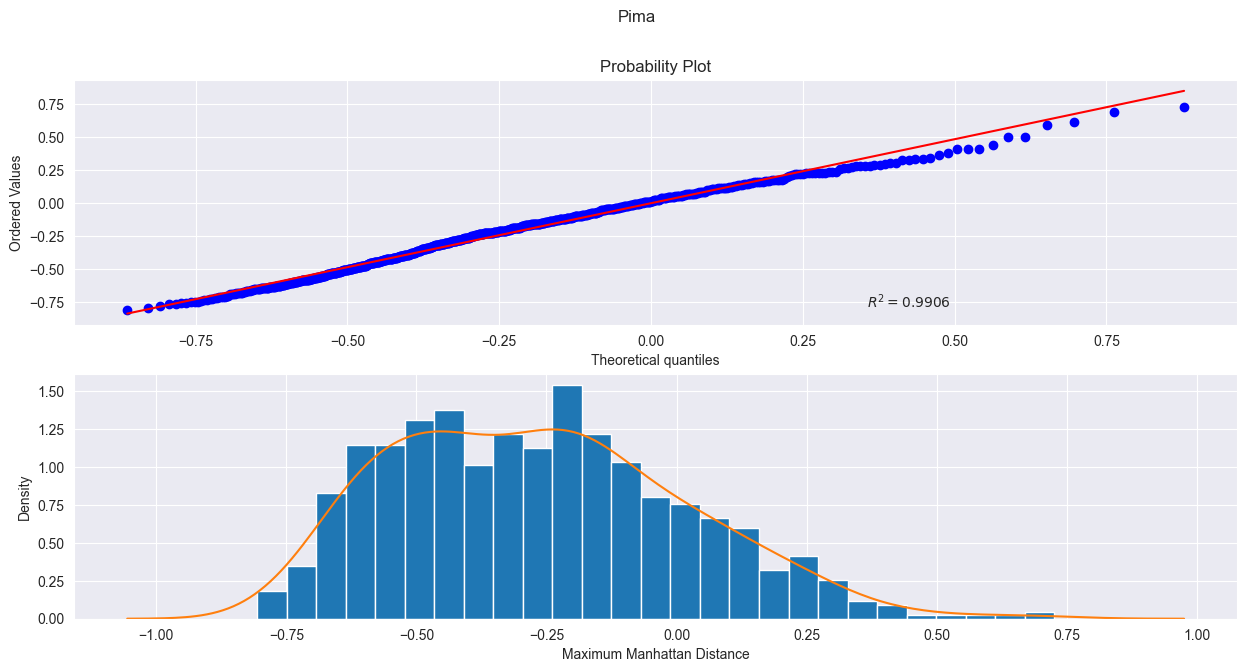

In [27]:
X, y = setupDf("real/Pima_withoutdupl_norm_35.arff")
endResults = outputResults(X, y)
printResults(endResults)
qqPlots(X,y,67,"Pima")

0.9873883021933388 15 [0.9289246547522341, 0.9783585499593827, 0.9790541226645003, 0.9832757920389926, 0.9827198415922015, 0.9855199025182778, 0.9848065597075549, 0.9867612713241267, 0.9863728675873273, 0.985981925264013, 0.9860479285134038, 0.9860733143785541, 0.9871598294069861, 0.9873883021933388, 0.9872613728675872, 0.9872461413484973, 0.9872740658001624, 0.9865658001624695, 0.9860733143785541, 0.9859971567831032, 0.9861012388302193, 0.9858194557270513, 0.9842150690495532, 0.9818846466287571, 0.9819861900893582, 0.9815267059301381, 0.9798740861088546, 0.9792597481722177, 0.9795872258326566, 0.9801177904142975, 0.9803158001624696, 0.9787545694557271, 0.9785007108042243, 0.978561636880585, 0.9789348090982941, 0.9790033509341998, 0.9776172826969945, 0.9769344029244516, 0.9766323111291633, 0.9760281275385865, 0.9759849715678309, 0.9757108042242079, 0.9759062753858652, 0.9759545085296506, 0.9745608245329, 0.9754391754671, 0.9752817831031683, 0.9731747562956946, 0.9747486799350124, 0.974

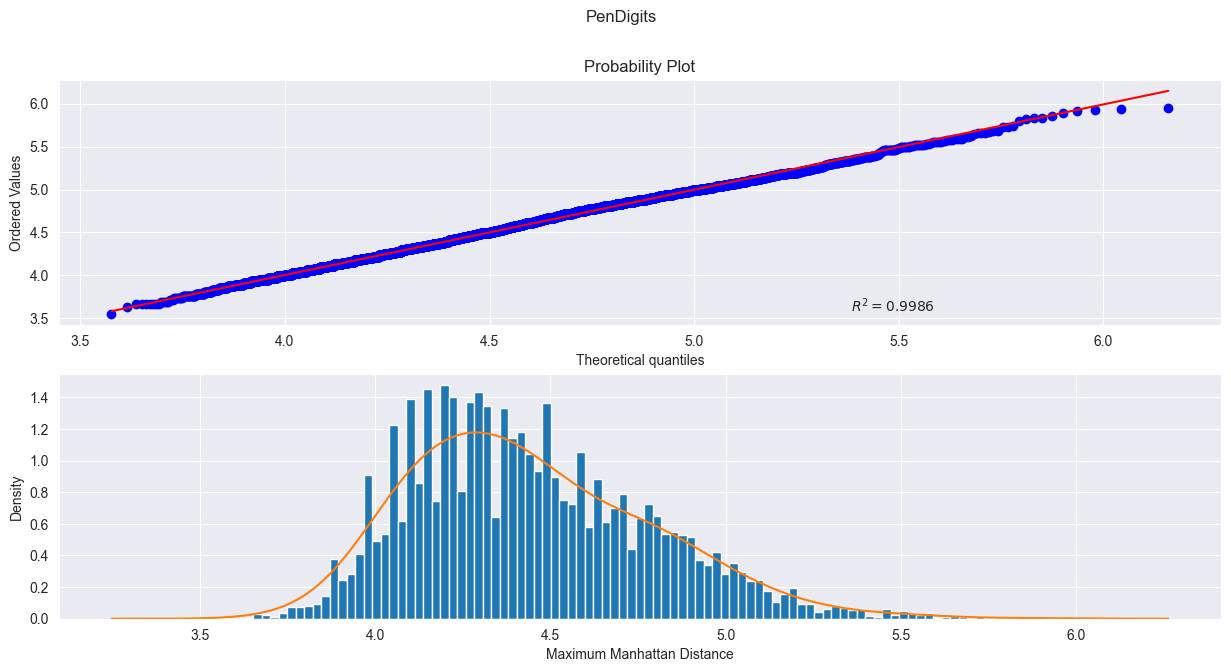

In [28]:
X, y = setupDf("real/PenDigits_withoutdupl_norm_v10.arff")
endResults = outputResults(X, y)
printResults(endResults)
qqPlots(X,y,15,"PenDigits")

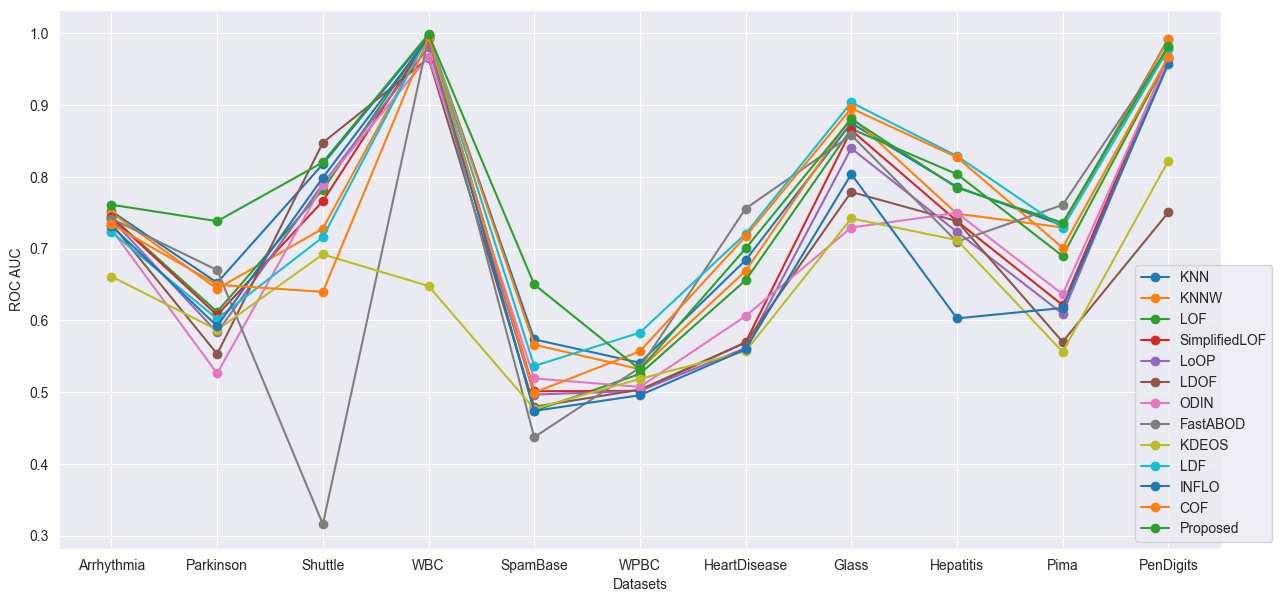

In [29]:
valuesperSet = [[0.752,0.75008,0.74421,0.74339,0.74111,0.73452,0.72669,0.74176,0.66101,0.72286,0.73154,0.73385,0.761081489734203],
[0.65235,0.64399,0.61196,0.60728,0.58312,0.55315,0.52608,0.66993,0.58673,0.60218,0.59198,0.64966,0.738166099773242],
[0.81762,0.72785,0.78208,0.76608,0.78992,0.84754,0.789,0.316,0.69192,0.71585,0.79885,0.63969,0.820153846153846],
[0.99718,0.99718,0.99671,0.9939,0.98028,0.96526,0.96737,0.99484,0.64789,0.99718,0.9939,0.99437,0.998591549295774],
[0.57347,0.56618,0.47384,0.50119,0.49658,0.4796,0.5191,0.43721,0.47667,0.53641,0.47381,0.49945,0.650009471053444],
[0.5409,0.53191,0.52543,0.50183,0.50183,0.50345,0.50726,0.53417,0.51853,0.58292,0.4957,0.55686,0.531562632098069],
[0.68383,0.66883,0.65583,0.56933,0.56139,0.56906,0.60592,0.75567,0.55694,0.72056,0.55967,0.71683,0.700166666666666],
[0.8748,0.8832,0.86667,0.86504,0.83957,0.77886,0.72927,0.85799,0.74201,0.90352,0.80379,0.89539,0.880487804878048],
[0.78588,0.74856,0.80367,0.73823,0.72331,0.73823,0.74971,0.70953,0.71183,0.82893,0.60276,0.82721,0.784730195177956],
[0.73224,0.72944,0.68955,0.62131,0.60922,0.57004,0.63637,0.76081,0.55621,0.72888,0.61728,0.70121,0.735914179104477],
[0.99212,0.9916,0.96581,0.9668,0.96231,0.75034,0.96432,0.97979,0.82214,0.97791,0.95712,0.96695,0.982605605199025],
]
datasets = ['Arrhythmia','Parkinson','Shuttle','WBC','SpamBase','WPBC','HeartDisease','Glass','Hepatitis','Pima','PenDigits']

algo = ['KNN','KNNW','LOF','SimplifiedLOF','LoOP','LDOF','ODIN','FastABOD','KDEOS','LDF','INFLO','COF','Proposed']

plt.plot(datasets,valuesperSet,marker='o')
plt.ylabel("ROC AUC")
plt.xlabel("Datasets")
plt.legend(algo,loc=4,bbox_to_anchor=(1.05,0))
plt.show()

In [30]:
mainDataFrame = mainDataFrame.reshape((-1, 2))
dfNew = pd.DataFrame(mainDataFrame, columns=['ROC AUC', 'K'])
dfNew.head(10)
dfNew.to_csv('Final_Data_LogNorm.csv', index=False)